# Experimento 3: Grad-CAM en Modelo Unimodal (CNN-LSTM)
Este notebook implementa **Grad-CAM** sobre el modelo unimodal **CNN-LSTM** (`ThermalCNNLSTM`).

Dado que este modelo es unimodal (solo procesa imágenes térmicas y **no** tiene variables tabulares contextuales), sirve como un **estudio de ablación** ideal. Veremos si la red visual, al no poder usar "atajos" tabulares, se ve forzada a buscar los gradientes físicos dentro de la silueta completa de la huella.

In [5]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

# Asegurar que la raíz esté en el PYTHONPATH para importar desde 'src'
sys.path.append(str(Path("..").resolve()))
sys.path.append(str(Path(".").resolve()))

from src.models.cnn_lstm import ThermalCNNLSTM
from src.loaders.cnn_lstm_loader import ThermalSequenceDataset

print("Bibliotecas importadas con éxito.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Bibliotecas importadas con éxito.
Usando dispositivo: cuda


## 1. Cargar el Dataset Secuencial y el Modelo CNN-LSTM
Cargamos `CNNLSTM_baseline.pt` y el dataset secuencial con tamaño de ventana temporal `seq_len = 5`.

In [6]:
csv_path = "../processed_data/metadata_train.csv" if Path("../processed_data/metadata_train.csv").exists() else "processed_data/metadata_train.csv"

dataset = ThermalSequenceDataset(
    metadata_csv=csv_path,
    is_train=False,
    min_time_s=0.0,
    seq_len=5
)
print(f"Ventanas secuenciales en validación: {len(dataset)}")

# Cargar modelo
model = ThermalCNNLSTM(lstm_hidden_dim=128, lstm_layers=1)
model_path = "../CNNLSTM_baseline.pt" if Path("../CNNLSTM_baseline.pt").exists() else "CNNLSTM_baseline.pt"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Pesos del modelo unimodal CNN-LSTM cargados con éxito.")

Ventanas secuenciales en validación: 2853
Pesos del modelo unimodal CNN-LSTM cargados con éxito.


## 2. Implementar Grad-CAM para Secuencias Temporales
El modelo CNN-LSTM aplana el lote y la dimensión temporal antes del backbone visual. 
Grad-CAM se calcula de manera simultánea en el espacio para cada fotograma de la ventana de entrada.

In [7]:
class SequenceGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registrar hooks en el backbone visual convolucional
        self.hook_a = target_layer.register_forward_hook(self.save_activation)
        self.hook_g = target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def __call__(self, x_seq):
        # x_seq: [1, L, 1, H, W]
        x_seq = x_seq.clone().detach().requires_grad_(True)
        
        # Desactivar cuDNN temporalmente para permitir backward del RNN en modo eval
        was_enabled = torch.backends.cudnn.enabled
        torch.backends.cudnn.enabled = False
        try:
            # Forward pass
            output = self.model(x_seq)
            
            # Backward pass sobre la estimación de tiempo
            self.model.zero_grad()
            output.backward()
        finally:
            torch.backends.cudnn.enabled = was_enabled
        
        gradients = self.gradients     # [L, C, H_feat, W_feat]
        activations = self.activations # [L, C, H_feat, W_feat]
        
        assert gradients is not None, "Gradientes vacíos."
        assert activations is not None, "Activaciones vacías."
        
        # Promedio espacial de gradientes (GAP)
        weights = torch.mean(gradients, dim=[2, 3], keepdim=True) # [L, C, 1, 1]
        
        # Combinación lineal por cada frame en la secuencia L
        cam = torch.sum(weights * activations, dim=1, keepdim=True) # [L, 1, H_feat, W_feat]
        cam = torch.relu(cam)
        
        # Normalizar cam a [0, 1] individualmente por fotograma
        L_dim = cam.shape[0]
        cam_min = cam.view(L_dim, -1).min(dim=-1, keepdim=True)[0].view(L_dim, 1, 1, 1)
        cam_max = cam.view(L_dim, -1).max(dim=-1, keepdim=True)[0].view(L_dim, 1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        
        return cam, output.detach()
        
    def remove_hooks(self):
        self.hook_a.remove()
        self.hook_g.remove()

print("SequenceGradCAM definida exitosamente.")

SequenceGradCAM definida exitosamente.


## 3. Auditar Secuencias Completas de Juandiego
Buscamos las ventanas móviles asociadas a **Juandiego en Madera** (`jua_woo_test1`) y **Juandiego en Vidrio** (`jua_gla_test1`). 
Graficaremos toda la ventana secuencial de 5 imágenes mostrando la progresión espacial de la atención.


Secuencia: jua_woo_test1 | Superficie: WOOD
Tiempo Real: 21.0s | Predicción Unimodal: 19.8s


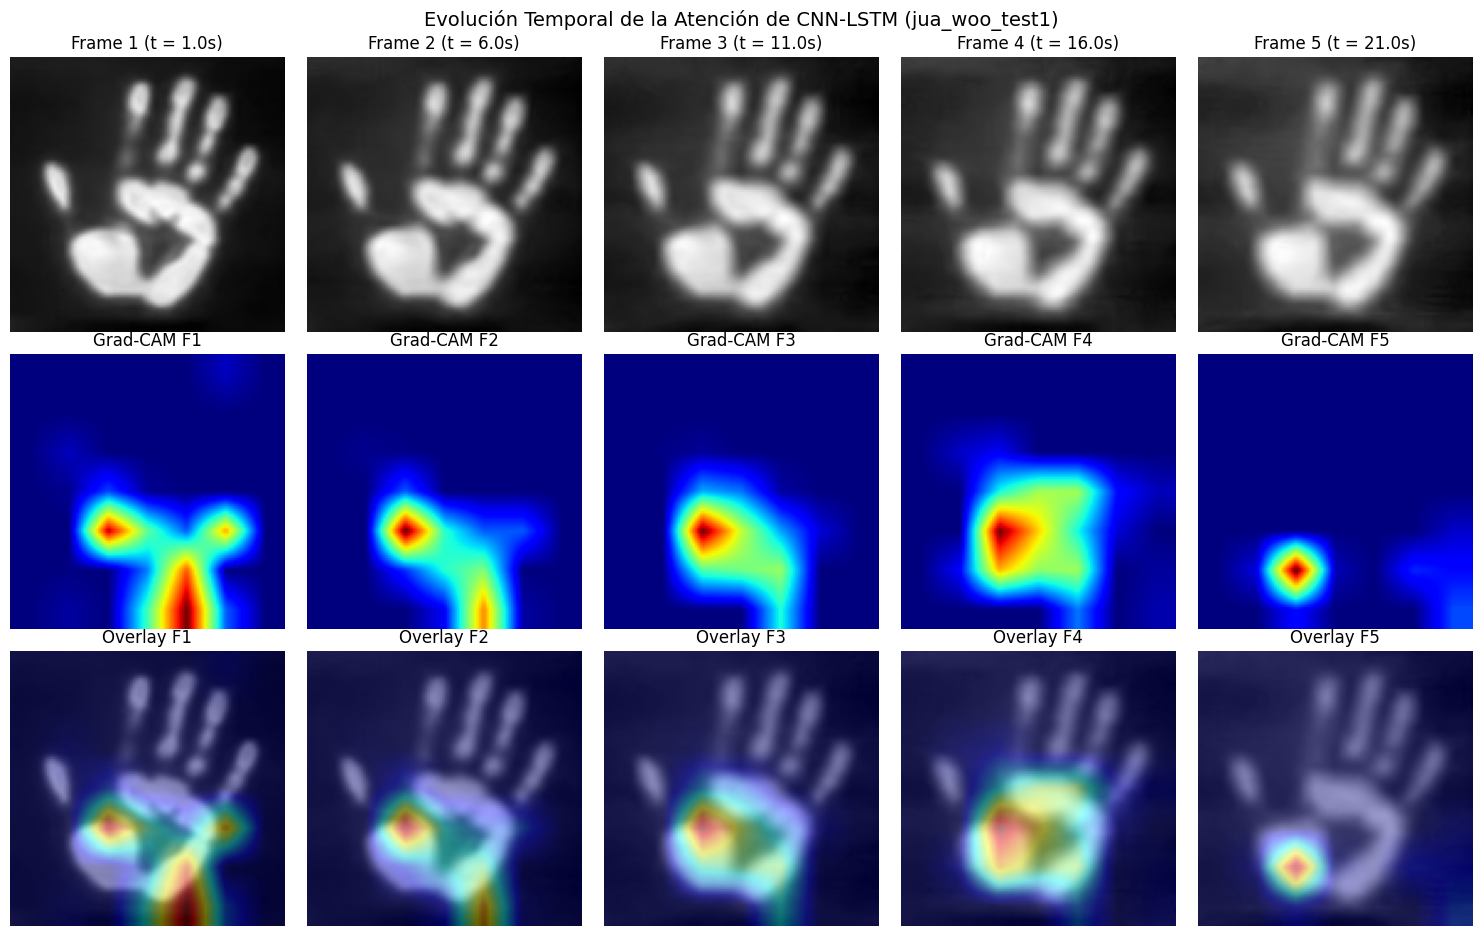


Secuencia: jua_gla_test1 | Superficie: GLASS
Tiempo Real: 21.1s | Predicción Unimodal: 25.1s


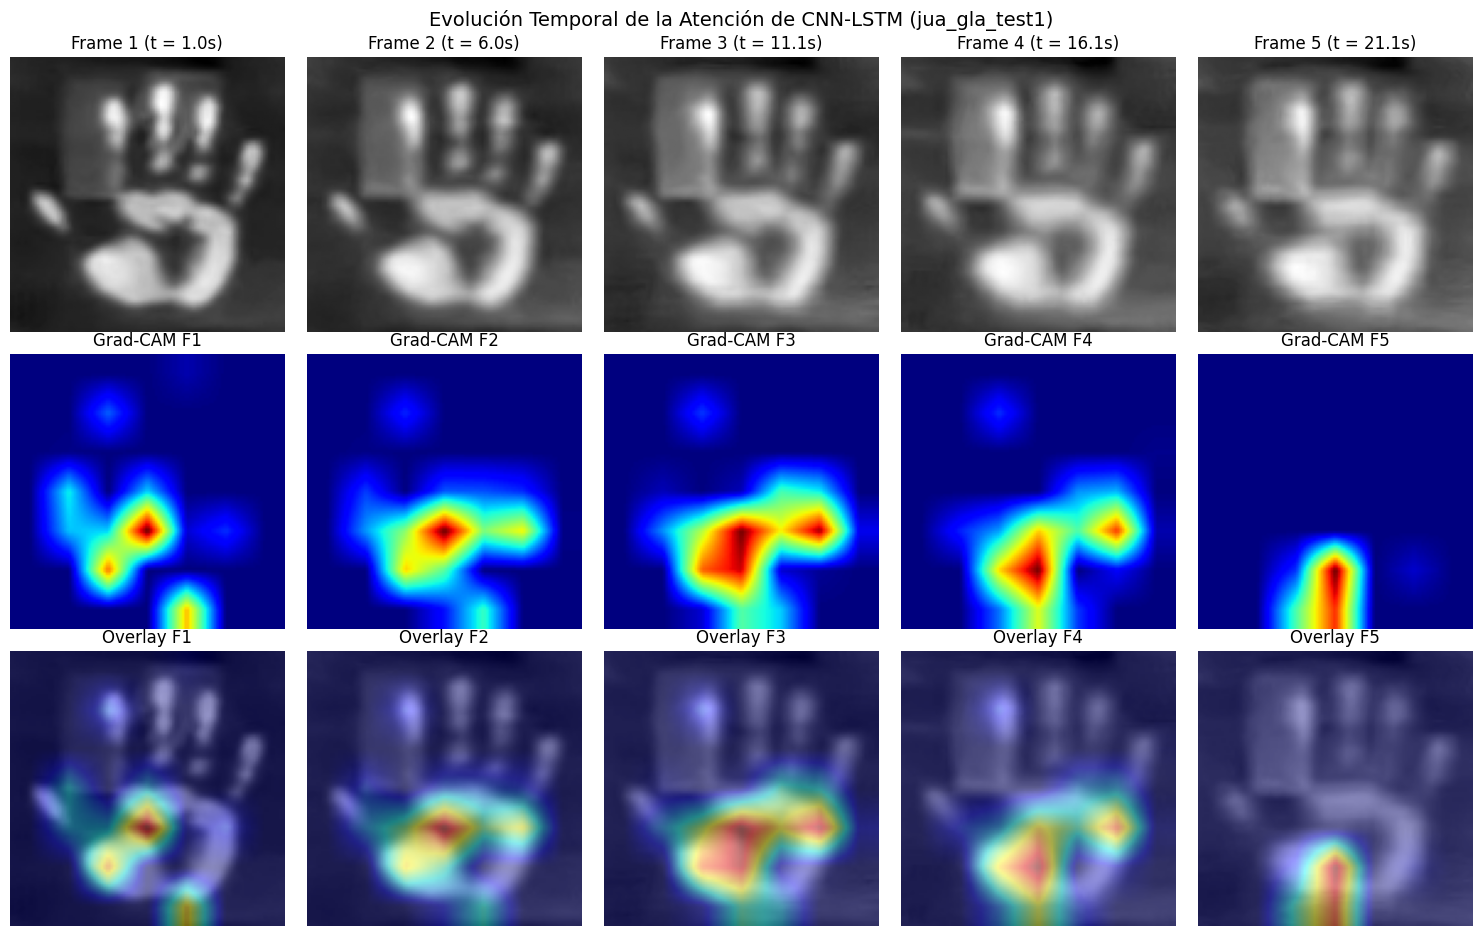

In [8]:
target_layer = model.backbone.stage4
gradcam = SequenceGradCAM(model, target_layer)

# Buscar ventanas correspondientes a las secuencias clave
window_wood_idx = None
window_glass_idx = None

for i, window in enumerate(dataset.windows):
    last_row = dataset.df.iloc[window[-1]]
    seq_id = last_row["sequence_id"]
    # Tomamos ventanas cercanas al inicio del enfriamiento para ver bien la huella
    if seq_id == "jua_woo_test1" and window_wood_idx is None:
        # Asegurar que sea una de las primeras ventanas
        if last_row["t_seconds"] <= 30.0:
            window_wood_idx = i
    if seq_id == "jua_gla_test1" and window_glass_idx is None:
        if last_row["t_seconds"] <= 30.0:
            window_glass_idx = i

indices_to_test = [idx for idx in [window_wood_idx, window_glass_idx] if idx is not None]

for w_idx in indices_to_test:
    x_seq, y_time = dataset[w_idx]
    window_indices = dataset.windows[w_idx]
    
    # Agregar dimensión batch e indicar dispositivo
    x_seq_tensor = x_seq.unsqueeze(0).to(device) # [1, seq_len, 1, 112, 112]
    
    # Obtener máscara Grad-CAM para los 5 frames
    cam_masks, pred = gradcam(x_seq_tensor)
    pred_time = pred.item()
    
    seq_id = dataset.df.iloc[window_indices[-1]]["sequence_id"]
    surf = dataset.df.iloc[window_indices[-1]]["surface"]
    
    print(f"\nSecuencia: {seq_id} | Superficie: {surf.upper()}")
    print(f"Tiempo Real: {y_time.item():.1f}s | Predicción Unimodal: {pred_time:.1f}s")
    
    # Graficar la secuencia completa de 5 frames (3 filas: Térmica, Máscara, Overlay)
    fig, axes = plt.subplots(3, 5, figsize=(15, 9.5))
    
    for t in range(5):
        row_meta = dataset.df.iloc[window_indices[t]]
        t_seconds = row_meta["t_seconds"]
        
        # Imagen original
        img_np = x_seq[t].squeeze().numpy()
        img_vis = ((img_np + 1.0) / 2.0 * 255).astype(np.uint8)
        
        # Máscara Grad-CAM del fotograma t
        cam_np = cam_masks[t].squeeze().cpu().numpy()
        cam_resize = cv2.resize(cam_np, (img_vis.shape[1], img_vis.shape[0]))
        
        cam_u8 = (255 * cam_resize).astype(np.uint8)
        heatmap = cv2.applyColorMap(cam_u8, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        # Superposición
        overlay = cv2.addWeighted(cv2.cvtColor(img_vis, cv2.COLOR_GRAY2RGB), 0.6, heatmap, 0.4, 0)
        
        # Graficar fila 1: Térmica
        axes[0, t].imshow(img_vis, cmap='gray')
        axes[0, t].set_title(f"Frame {t+1} (t = {t_seconds:.1f}s)")
        axes[0, t].axis('off')
        
        # Graficar fila 2: Grad-CAM
        axes[1, t].imshow(cam_resize, cmap='jet')
        axes[1, t].set_title(f"Grad-CAM F{t+1}")
        axes[1, t].axis('off')
        
        # Graficar fila 3: Overlay
        axes[2, t].imshow(overlay)
        axes[2, t].set_title(f"Overlay F{t+1}")
        axes[2, t].axis('off')
        
    plt.suptitle(f"Evolución Temporal de la Atención de CNN-LSTM ({seq_id})", fontsize=14)
    plt.tight_layout()
    plt.show()

gradcam.remove_hooks()

## Análisis de Resultados del Estudio de Ablación
1. **¿El modelo unimodal se centra en la huella?** Compara estas máscaras con las del modelo multimodal `MTDE-Net`. Observarás que en este modelo unimodal la atención se concentra directamente en la **silueta de la huella dactilar (dedos y palma)** y no en el borde de recorte inferior.
2. **Por qué sucede esto:** Como el modelo unimodal no dispone del vector tabular de ayuda (no puede "hacer trampa" leyendo variables como la temperatura máxima o el área del hot-spot), la red visual no tiene otra opción más que aprender a buscar la disipación de calor dentro de los propios contornos del rastro de la mano.